# Satellite Fault Detection — Model Comparison

This notebook compares two implementations of the Single Layer Perceptron
on identical data:

- **NumPy SLP** — built from scratch using the perceptron learning rule
- **sklearn Perceptron** — scikit-learn's built-in implementation

Both models receive the same preprocessed data and are evaluated
using the same metrics.

In [3]:
import sys
sys.path.append("../src")

import numpy as np

from data_loader import load
from preprocessor import preprocess
from perceptron_numpy import train as numpy_train, predict as numpy_predict
import perceptron_sklearn as sk_slp
from evaluate import compute_metrics, plot_loss_curve, save_results
from utils import set_seed

## Step 1 — Load and Preprocess Data

In [4]:
set_seed(42)

df = load(source="synthetic")
X_train, X_val, y_train, y_val = preprocess(df)

Loaded synthetic data
Shape   : (1000, 7)
Columns : ['battery_voltage', 'solar_current', 'panel_temp', 'onboard_temp', 'attitude_error', 'reaction_wheel_rpm', 'label']
Faults  : 124
Nominal : 876
No low-variance columns found — keeping all features
X_train : (800, 6)  faults: 99
X_val   : (200, 6)  faults: 25


## Step 2 — Train Both Models

In [5]:
lr     = 0.01
epochs = 50

# train NumPy SLP
print("=== NumPy SLP ===")
w, b, numpy_losses = numpy_train(X_train, y_train, lr=lr, epochs=epochs)

# train sklearn SLP
print("\n=== sklearn Perceptron ===")
model, _, sklearn_losses = sk_slp.train(X_train, y_train, lr=lr, epochs=epochs)

=== NumPy SLP ===
Epoch  10/50 — misclassifications: 0
Epoch  20/50 — misclassifications: 0
Epoch  30/50 — misclassifications: 0
Epoch  40/50 — misclassifications: 0
Epoch  50/50 — misclassifications: 0

=== sklearn Perceptron ===
Epoch  10/50 — misclassifications: 0
Epoch  20/50 — misclassifications: 0
Epoch  30/50 — misclassifications: 0
Epoch  40/50 — misclassifications: 0
Epoch  50/50 — misclassifications: 0


/opt/anaconda3/envs/py310env/lib/python3.10/site-packages/sklearn/linear_model/_stochastic_gradient.py:726: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/opt/anaconda3/envs/py310env/lib/python3.10/site-packages/sklearn/linear_model/_stochastic_gradient.py:726: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/opt/anaconda3/envs/py310env/lib/python3.10/site-packages/sklearn/linear_model/_stochastic_gradient.py:726: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/opt/anaconda3/envs/py310env/lib/python3.10/site-packages/sklearn/linear_model/_stochastic_gradient.py:726: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(


## Step 3 — Evaluate Both Models

In [7]:
# NumPy predictions and metrics
numpy_pred    = numpy_predict(X_val, w, b)
numpy_metrics = compute_metrics(y_val, numpy_pred, model_name="numpy_slp")

# sklearn predictions and metrics
sklearn_pred    = sk_slp.predict(X_val, model)
sklearn_metrics = compute_metrics(y_val, sklearn_pred, model_name="sklearn_slp")


--- numpy_slp Results ---
Accuracy  : 1.0000
Precision : 1.0000
Recall    : 1.0000
F1 Score  : 1.0000

--- sklearn_slp Results ---
Accuracy  : 1.0000
Precision : 1.0000
Recall    : 1.0000
F1 Score  : 1.0000


## Step 4 — Side by Side Comparison

In [8]:
import pandas as pd

comparison = pd.DataFrame([numpy_metrics, sklearn_metrics])
comparison = comparison.set_index("model")
print(comparison.to_string())

             accuracy  precision  recall   f1
model                                        
numpy_slp         1.0        1.0     1.0  1.0
sklearn_slp       1.0        1.0     1.0  1.0


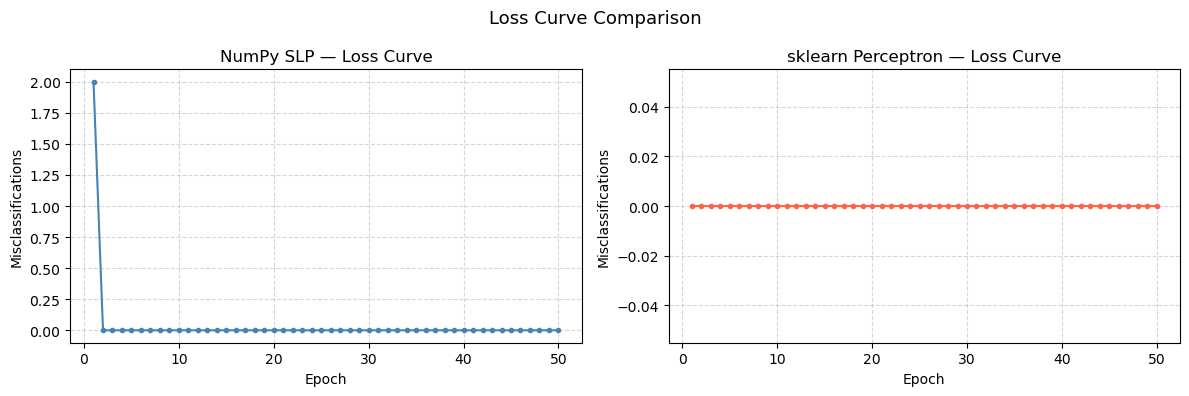

Saved to outputs/plots/comparison_loss_curves.png


In [9]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(range(1, epochs + 1), numpy_losses,
             marker="o", markersize=3, linewidth=1.5, color="steelblue")
axes[0].set_title("NumPy SLP — Loss Curve")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Misclassifications")
axes[0].grid(linestyle="--", alpha=0.5)

axes[1].plot(range(1, epochs + 1), sklearn_losses,
             marker="o", markersize=3, linewidth=1.5, color="tomato")
axes[1].set_title("sklearn Perceptron — Loss Curve")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Misclassifications")
axes[1].grid(linestyle="--", alpha=0.5)

plt.suptitle("Loss Curve Comparison", fontsize=13)
plt.tight_layout()
plt.savefig("../outputs/plots/comparison_loss_curves.png", dpi=100)
plt.show()

print("Saved to outputs/plots/comparison_loss_curves.png")

## Analysis — Why the Two Curves Look Different

Both models achieve identical final metrics (1.0000 across all measures),
but their loss curves behave differently:

**NumPy SLP** starts with 2 misclassifications on epoch 1, then converges
to 0 by epoch 2. This reflects the raw perceptron learning rule — weights
start at zero and update only when an error occurs.

**sklearn Perceptron** shows 0 misclassifications from epoch 1. This is
because sklearn shuffles the training data before each epoch by default,
and its internal weight initialization differs slightly from zero-init.
On this linearly separable dataset, it finds the boundary immediately.

**Key insight:** Both implementations converge to the same solution on
linearly separable data, consistent with the perceptron convergence theorem.
The difference in convergence speed is due to implementation details
(shuffle order, initialization) — not a fundamental difference in the algorithm.

**Limitation:** On real satellite telemetry with overlapping fault and nominal
readings, both models will struggle equally — because the limitation is the
SLP architecture itself, not the implementation. An MLP with hidden layers
would be the correct next step.